In [ ]:
%pip install plotly
%pip install shap

#### Import necesssary libarays 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score, 
    f1_score,
    precision_score,
    recall_score,
    log_loss,
    brier_score_loss,
    confusion_matrix

)
import optuna
import lightgbm as lgb
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibratedClassifierCV
import shap
from catboost import CatBoostClassifier
import seaborn as sns
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import average_precision_score
from sklearn.model_selection import ParameterSampler

/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the cleaned dataset  
df = pd.read_csv("/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/data/lendingclub_model_cleaned.csv")

In [4]:
# create a column issue date 
# combines the month and year for issue date in each column.
# will be used later to seperate the training, test, and validation sets for X and y
df["issue_date"] = pd.to_datetime(
    df["issue_d_year"].astype(str) + "-" +
    df["issue_d_month"].astype(str)
)

df = df.sort_values("issue_date")

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_31667/1511764817.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["issue_date"] = pd.to_datetime(


In [5]:
#sort the dataframe by date
df = df.sort_values("issue_date")

In [6]:
#Get the max and min values from issue date
print(df["issue_date"].min())
print(df["issue_date"].max())

2012-06-01 00:00:00
2018-12-01 00:00:00


In [7]:
# create the varibles X and y 
y = df["default"]
X = df.drop(columns=["default","emp_title","title","issue_date"])

In [8]:
#get the max and min issue date 
df["issue_date"].min(), df["issue_date"].max()

# group the issue dates by year 
# count the num y values per year
df.groupby(df["issue_date"].dt.year)["default"].mean()

issue_date
2012    0.161342
2013    0.155408
2014    0.183967
2015    0.201228
2016    0.228045
2017    0.228491
2018    0.149305
Name: default, dtype: float64

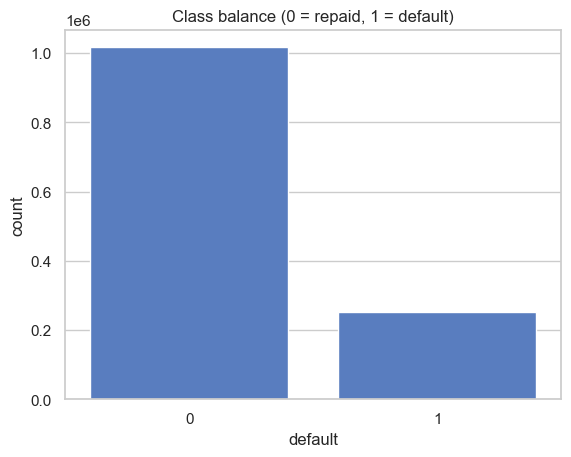

In [9]:
# count each group for default = y 
sns.set_theme(style="whitegrid", palette="muted")
sns.countplot(x='default', data=df)
plt.title('Class balance (0 = repaid, 1 = default)'); 
plt.show()


This visualization function plots the distribution of all numeric features in the dataset, with special handling for different feature types.

Binary features (0/1 variables) are plotted using simple histograms to show class balance.
Continuous features are visualized using clipped histograms (99th percentile) to reduce distortion from extreme outliers.

For zero-inflated count features (features with a high proportion of zeros, e.g., tax liens), the plot highlights the distribution of zero vs non-zero values and also provides a log-scaled view of the non-zero portion.

This approach ensures that each feature is visualized in a way that reflects its underlying structure, rather than being distorted by scale differences or rare extreme values.

In [10]:
def plot_hist(X):

    num_cols = X.select_dtypes(include=np.number).columns

    n_cols = 4
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(20, 5 * n_rows),
        sharex=False,
        sharey=False
    )

    axes = axes.flatten()

    for i, col in enumerate(num_cols):

        data = X[col].dropna()

        # CASE 1: binary features (0/1)
        if data.nunique() == 2 and set(data.unique()).issubset({0, 1}):
            axes[i].hist(data, bins=2)
            axes[i].set_title(f"{col} (binary)")
            axes[i].tick_params(axis='x', labelrotation=45)
            continue

        # CASE 2: zero-inflated count features
        zero_ratio = (data == 0).mean()

        if zero_ratio > 0.5:
            non_zero = data[data > 0]

            axes[i].hist(data, bins=2)
            axes[i].set_title(f"{col} (0 vs non-zero: {zero_ratio:.2f})")

            if len(non_zero) > 0:
                ax2 = axes[i].inset_axes([0.55, 0.55, 0.4, 0.4])
                ax2.hist(np.log1p(non_zero), bins=20)
                ax2.set_title("log(non-zero)")
                ax2.tick_params(labelsize=6)

            continue

        # CASE 3: continuous features
        upper = data.quantile(0.99)
        clipped = data[data <= upper]

        axes[i].hist(clipped, bins=80)
        axes[i].set_title(f"{col} (clipped 99%)")
        axes[i].tick_params(axis='x', labelrotation=45)

    # remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

In [11]:
def correlation_target_pruning(X, y, corr_threshold=0.90):
    """
    Feature selection method that removes redundant features using:
    
    1. Feature-feature correlation (X vs X) to detect redundancy
    2. Feature-target correlation (X vs y) to keep most predictive feature

    Strategy:
    - Identify highly correlated numeric feature pairs
    - For each pair, compare absolute correlation with target (y)
    - Drop the feature that has weaker relationship with y

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix (must NOT include target variable)
    
    y : pd.Series or np.array
        Target variable
    
    corr_threshold : float
        Threshold above which two features are considered redundant

    Returns
    -------
    X_reduced : pd.DataFrame
        Reduced feature set after pruning
    
    dropped_features : list
        Features removed during pruning
    """
    #get the numeric features of x 
    X_numeric = X.select_dtypes(include=[np.number]).copy()

    # Compute feature-feature correlation matrix
    corr_matrix = X_numeric.corr().abs()

    # Take upper triangle to avoid duplicate pairs
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    target_corr = X_numeric.apply(lambda col: col.corr(y)).abs()
    high_corr_pairs = []

    for col in upper.columns:
        for row in upper.index:
            if upper.loc[row, col] > corr_threshold:
                high_corr_pairs.append((row, col))
    
    to_drop = set()
    for f1, f2 in high_corr_pairs:
        # skip if already dropped
        if f1 in to_drop or f2 in to_drop:
            continue

        # compare predictive strength
        if target_corr[f1] >= target_corr[f2]:
            to_drop.add(f2)
        else:
            to_drop.add(f1)

    X_reduced = X.drop(columns=list(to_drop), errors="ignore")
    return X_reduced, list(to_drop)

In [12]:
def get_time_split(df, X, y, start_train, end_train, end_val):

    train_mask = (df["issue_date"] >= start_train) & (df["issue_date"] <= end_train)
    val_mask   = (df["issue_date"] > end_train) & (df["issue_date"] <= end_val)

    X_train = X.loc[train_mask]
    y_train = y.loc[train_mask]

    X_val = X.loc[val_mask]
    y_val = y.loc[val_mask]

    test_mask  = df["issue_date"] > "2017-12-01"
    X_test = X[test_mask]
    y_test = y[test_mask]

    return X_train, X_val,X_test, y_train, y_val, y_test

In [13]:
X, droplist=correlation_target_pruning(X, y, corr_threshold=0.95)

/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/venv311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/mariahwaslie/Desktop/Coding Projects/stats-ML/venv311/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [14]:
print(X.shape) # get num of (rows, cols) in X
print(y.shape) # (rows, )

(1269822, 93)
(1269822,)


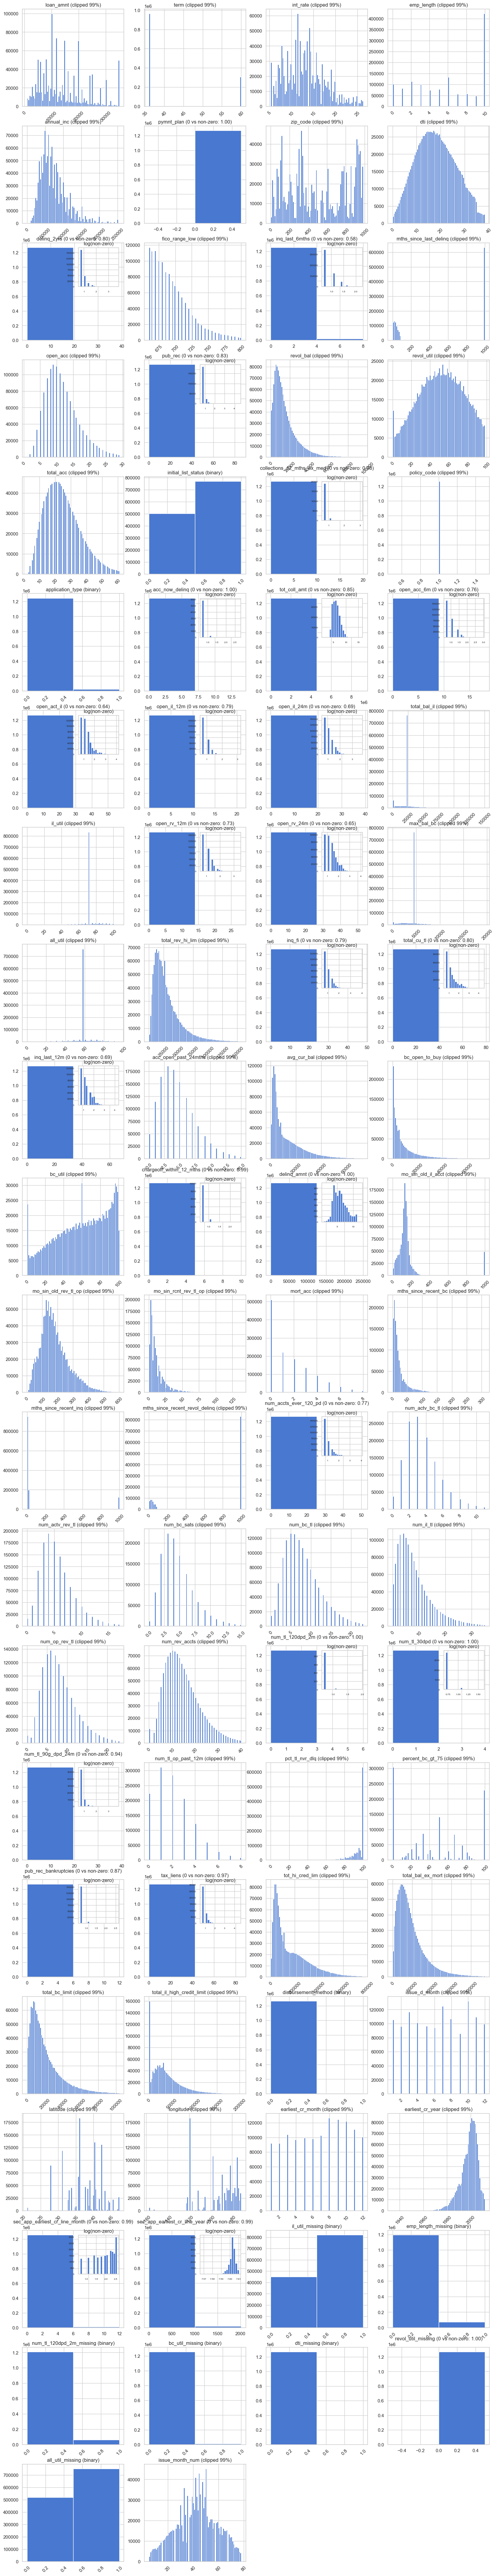

In [16]:
#plot the histogram 
plot_hist(X)

#### Temporal Validation

This model uses a time-based split, where training is performed on older loans and evaluation is performed on more recent loans.

This approach is critical for real-world credit risk modeling because loan data is inherently time-dependent. Borrower behavior, underwriting standards, and macroeconomic conditions change over time, leading to concept drift.

Unlike random splits, a chronological split ensures that the model is evaluated on truly unseen future data, making performance estimates more realistic and aligned with deployment conditions.

The results show that performance remains relatively stable across time splits, indicating that the model generalizes reasonably well to future loan cohorts. However, some performance degradation on later data suggests mild distribution shift, which is expected in financial datasets.

In [17]:
# split X and y given the function (time-based)
X_train, X_val,X_test, y_train, y_val, y_test= get_time_split(df=df,X=X,y=y,start_train="2012-06-01",end_train="2016-12-01", end_val="2017-12-01" )

In [18]:
#get the names of all categorical columns 
categorical_cols = [
    col for col in X.select_dtypes(include="object")
]
# change each col non-numeric to the type of category 
for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_test[col] = X_test[col].astype("category")
    X_val[col] = X_val[col].astype("category")

#view the list of categorical cols     
print(categorical_cols)

/var/folders/zz/8h6rnwtn2s3759zf_90928740000gn/T/ipykernel_31667/3215526973.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in X.select_dtypes(include="object")


['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'verification_status_joint']


### Hyperparameter tuning 

In [ ]:

param_grid = {
    "depth": [6, 7, 8],
    "learning_rate": [0.01,0.05,0.1],
    "iterations": [300,500,800, 1000],
    "l2_leaf_reg": [3, 5, 7, 9]
}

best_score = -1
best_params = None
count =0

for params in ParameterGrid(param_grid):

    model = CatBoostClassifier(
        **params,
        loss_function='Logloss',
        eval_metric='PRAUC',
        verbose=0,
        random_state=42
    )

    model.fit(X_train, y_train, cat_features=categorical_cols)

    preds = model.predict_proba(X_test)[:, 1]
    score = average_precision_score(y_test, preds)
    count +=1
    print(count)

    if score > best_score:
        best_score = score
        best_params = params

        print("Best score:", best_score)
        print("Best params:", best_params)

Best score: 0.3288767651115585

Best params: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 3, 'learning_rate': 0.1}

#### Train the model with the optimal hyperparameters

In [19]:

cat_boost_model = CatBoostClassifier(

        iterations=1000,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=3, 
        loss_function='Logloss',
        eval_metric='PRAUC',        
        random_seed=42,
        verbose=0
    )

cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_boost_model.fit(
        X_train,
        y_train,
        cat_features=cat_cols

    )

CatBoostClassifier(depth=6, eval_metric='PRAUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

In [20]:
def evaluate_classifier(model, X_test, y_test, threshold=0.5):

    # Predicted probabilities
    y_prob = model.predict_proba(X_test)[:, 1]

    # Predicted classes
    y_pred = (y_prob >= threshold).astype(int)

    # Metrics
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    ll = log_loss(y_test, y_prob)
    brier = brier_score_loss(y_test, y_prob)

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"Threshold:    {threshold:.4f}")
    print(f"ROC-AUC:      {roc_auc:.4f}")
    print(f"PR-AUC:       {pr_auc:.4f}")
    print(f"Log Loss:     {ll:.4f}")
    print(f"Brier Score:  {brier:.4f}")
    print(f"Precision:    {precision:.4f}")
    print(f"Recall:       {recall:.4f}")
    print(f"F1 Score:     {f1:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "ROC_AUC": roc_auc,
        "PR_AUC": pr_auc,
        "LogLoss": ll,
        "Brier": brier,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }

In [21]:
# get metrics for the model
metrics = evaluate_classifier(cat_boost_model, X_test=X_test, y_test=y_test)

Threshold:    0.5000
ROC-AUC:      0.7350
PR-AUC:       0.3289
Log Loss:     0.3905
Brier Score:  0.1201
Precision:    0.4598
Recall:       0.1457
F1 Score:     0.2213

Confusion Matrix:
[[45958  1424]
 [ 7104  1212]]


#### SHAP Feature importances

In [22]:
# create new shap explainer given your model
explainer = shap.TreeExplainer(cat_boost_model)

# get the shap values for the model
shap_values = explainer.shap_values(X_train)

# calculate the shap importance 
shap_importance = np.abs(shap_values).mean(axis=0)

# create a df that contains the features with coorosponding feature importances 
shap_df = pd.DataFrame({
    "feature": X_train.columns,
    "shap_importance": shap_importance
}).sort_values("shap_importance", ascending=False)

#view the top 30 features in the model
shap_df.head(30)

,feature,shap_importance
2,int_rate,0.297609
1,term,0.269423
12,dti,0.152409
0,loan_amnt,0.145460
92,issue_month_num,0.142716
43,acc_open_past_24mths,0.122435
7,annual_inc,0.093099
6,home_ownership,0.090649
14,fico_range_low,0.079144
74,total_bc_limit,0.067028


In [23]:
#get the size of X (rows, cols)
print(X_train.shape)

#get the bottom 20 features 
shap_df.tail(20)

(1045575, 93)


,feature,shap_importance
22,initial_list_status,0.001276
66,num_tl_90g_dpd_24m,0.001218
25,application_type,0.000927
47,chargeoff_within_12_mths,0.000820
71,tax_liens,0.000594
87,bc_util_missing,0.000251
48,delinq_amnt,0.000179
64,num_tl_120dpd_2m,0.000065
65,num_tl_30dpd,0.000061
76,disbursement_method,0.000060


In [24]:
#features that willl be removed 
features_to_remove = shap_df.tail(18)["feature"].tolist()
print(features_to_remove)

['application_type', 'chargeoff_within_12_mths', 'tax_liens', 'bc_util_missing', 'delinq_amnt', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'disbursement_method', 'acc_now_delinq', 'pymnt_plan', 'sec_app_earliest_cr_line_month', 'policy_code', 'il_util_missing', 'dti_missing', 'revol_util_missing', 'all_util_missing', 'dti_is_corrupt', 'sec_app_earliest_cr_line_year']


In [25]:
# remove least important features 
X_reduced= X.drop(columns=features_to_remove)
X_train, X_val,X_test, y_train, y_val, y_test= get_time_split(df, X_reduced, y, start_train="2012-06-01",end_train="2016-12-01", end_val="2017-12-01")

In [26]:
# get the new shape of X (rows, cols)
X_reduced.shape

(1269822, 75)

In [27]:
# retrain the model with unimportant features removed 
cat_boost_model = CatBoostClassifier(
        iterations=1000,
        learning_rate=0.1,
        depth=6,
        l2_leaf_reg=3, 
        loss_function='Logloss',
        eval_metric='PRAUC',        
        random_seed=42,
        verbose=0
    )

cat_boost_model.fit(
        X_train,
        y_train,
        cat_features=cat_cols

    )

CatBoostClassifier(depth=6, eval_metric='PRAUC', iterations=1000, l2_leaf_reg=3, learning_rate=0.1, loss_function='Logloss', random_seed=42, verbose=0)

##### SHAP Feature Importance

SHAP values quantify how much each feature contributes to the model’s predictions. Features with larger absolute SHAP values have a greater influence on the model’s decision-making process.

The summary plot below provides insight into how the model evaluates loan applications:

* Features are ranked from most important to least important based on their average impact on predictions.
* Each point represents an individual loan application.
* Feature values are color-coded, where red indicates higher feature values and blue indicates lower feature values.
* The position along the x-axis shows whether a feature increased or decreased the predicted probability of loan default.
* Features with points farther from zero have a stronger influence on the model’s predictions.

This visualization helps identify which borrower characteristics have the greatest impact on default risk and how those characteristics affect the model’s predictions. SHAP values were also used during feature selection to identify low-impact variables that could be removed while maintaining model performance.

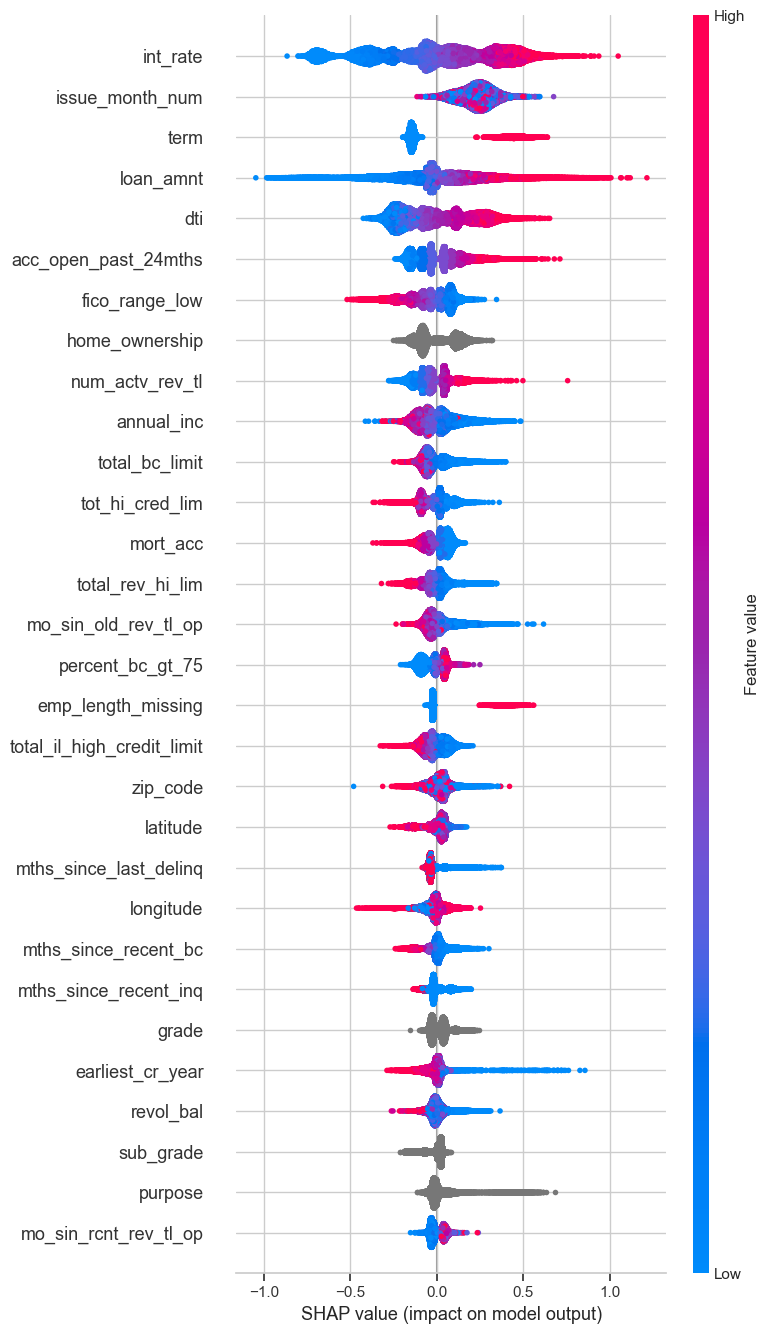

In [28]:
explainer = shap.TreeExplainer(cat_boost_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    shap_values,
    X_test,
    max_display= 30
)

In [29]:
# get the new metrics after reducing the features 
metrics = evaluate_classifier(cat_boost_model, X_test=X_test, y_test=y_test)

Threshold:    0.5000
ROC-AUC:      0.7353
PR-AUC:       0.3269
Log Loss:     0.3912
Brier Score:  0.1205
Precision:    0.4448
Recall:       0.1477
F1 Score:     0.2217

Confusion Matrix:
[[45849  1533]
 [ 7088  1228]]


### check for overfitting models 
 ROC-AUC remains stable across training, validation, and test sets, with only a ~2 percentage point decrease from train to test. Thi limited train-test gap suggests minimal overfitting. A larger decline in Average Precision on the test set likely reflects temporal distribution shift in borrower characteristics and default behavior rather than model memorization, as the project uses a realistic time-based train-test split.

In [30]:
# Predicted probabilities
train_probs = cat_boost_model.predict_proba(X_train)[:, 1]
val_probs   = cat_boost_model.predict_proba(X_val)[:, 1]
test_probs  = cat_boost_model.predict_proba(X_test)[:, 1]

# Metrics
train_auc = roc_auc_score(y_train, train_probs)
val_auc   = roc_auc_score(y_val, val_probs)
test_auc  = roc_auc_score(y_test, test_probs)
train_ap = average_precision_score(y_train, train_probs)
val_ap   = average_precision_score(y_val, val_probs)
test_ap  = average_precision_score(y_test, test_probs)
train_ll = log_loss(y_train, train_probs)
test_ll  = log_loss(y_test, test_probs)

# Display results

print("MODEL PERFORMANCE")
print("\nROC-AUC")
print(f"{'Train:':<12}{train_auc:>10.4f}")
print(f"{'Validation:':<12}{val_auc:>10.4f}")
print(f"{'Test:':<12}{test_auc:>10.4f}")

print("\nAverage Precision (PR-AUC)")
print(f"{'Train:':<12}{train_ap:>10.4f}")
print(f"{'Validation:':<12}{val_ap:>10.4f}")
print(f"{'Test:':<12}{test_ap:>10.4f}")

print("\nLog Loss")
print(f"{'Train:':<12}{train_ll:>10.4f}")
print(f"{'Test:':<12}{test_ll:>10.4f}")

print("\nActual Positive Rates")
print(f"{'Train:':<12}{y_train.mean():>10.4%}")
print(f"{'Validation:':<12}{y_val.mean():>10.4%}")
print(f"{'Test:':<12}{y_test.mean():>10.4%}")

MODEL PERFORMANCE

ROC-AUC
Train:          0.7562
Validation:     0.7361
Test:           0.7353

Average Precision (PR-AUC)
Train:          0.4530
Validation:     0.4454
Test:           0.3269

Log Loss
Train:          0.4264
Test:           0.3912

Actual Positive Rates
Train:        19.7306%
Validation:   22.8491%
Test:         14.9305%


#### Probability Calibration

While discrimination metrics such as ROC-AUC and PR-AUC measure how effectively a model separates defaulters from non-defaulters, they do not indicate whether the predicted probabilities correspond to true default risk. In credit risk applications, accurate probability estimates are important because lending decisions are often based on predicted risk levels rather than class labels alone.

To evaluate probability calibration, the CatBoost model was calibrated using isotonic regression through CalibratedClassifierCV. Isotonic calibration was selected because it can capture non-linear relationships between predicted and observed probabilities without imposing a fixed functional form. The calibration model was fitted using the validation dataset and subsequently applied to the test set. Calibration performance was assessed using reliability diagrams, Brier Score, and Expected Calibration Error (ECE), which collectively measure the agreement between predicted probabilities and observed default frequencies.

In [31]:
prob_true, prob_pred = calibration_curve(
    y_test,
    test_probs,
    n_bins=10,
    strategy="quantile"
)

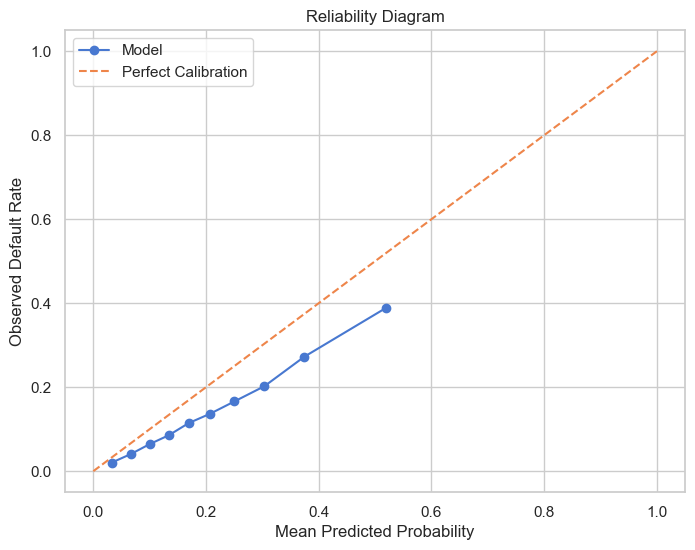

In [32]:
#plot the calibration curve 
plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker="o", label="Model")
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Reliability Diagram")
plt.legend()

plt.show()

In [33]:
iso_model = CalibratedClassifierCV(
    estimator=cat_boost_model,
    method="isotonic",
    cv=15
)

iso_model.fit(
        X_val,
        y_val,
        cat_features=cat_cols
    )

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","CatBoostClass...42, verbose=0)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",15
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'


In [34]:
y_prob = iso_model.predict_proba(X_test)[:,1]
prob_true_cal, prob_pred_cal = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="quantile"
)

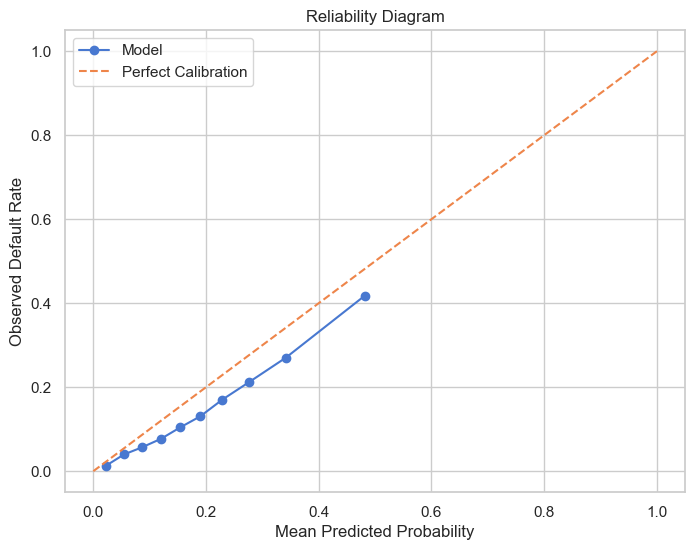

In [35]:
#plot the calibration curve 
plt.figure(figsize=(8,6))
plt.plot(prob_pred_cal, prob_true_cal, marker="o", label="Model")
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Default Rate")
plt.title("Reliability Diagram")
plt.legend()

plt.show()

### Calibration Analysis

#### Reliability Diagram Interpretation

The reliability diagram indicates that the calibrated model produces probability estimates that are reasonably aligned with observed default rates across the full range of predicted risk. As predicted probabilities increase from approximately 0.023 to 0.48, the observed default rate increases from 0.01 to 0.42, demonstrating a strong monotonic relationship between predicted and actual risk.

The model exhibits a slight tendency toward overestimation, particularly within the lower and middle probability ranges. For example, a predicted default probability of 0.120 corresponds to an observed default rate of 0.077, while a predicted probability of 0.229 corresponds to an observed rate of 0.170. At higher risk levels, calibration improves substantially, with predicted and observed default rates becoming more closely aligned.

#### Calibration Quality

The calibrated model achieved a Brier Score of 0.1151, indicating a relatively low average squared error between predicted probabilities and observed outcomes. In addition, the model achieved an Expected Calibration Error (ECE) of 0.0464, suggesting that the average discrepancy between predicted probabilities and observed default frequencies is approximately 4.6 percentage points across calibration bins.

These results indicate that the calibration procedure successfully improved the interpretability of the model’s probability estimates while preserving the model’s ability to rank risk. Although some overestimation remains in lower-risk segments, the magnitude of the calibration error is relatively small and does not indicate severe systematic miscalibration.

#### Conclusion

Overall, the calibrated CatBoost model demonstrates good probability calibration and produces risk estimates that are broadly consistent with observed default behavior. The combination of a low Brier Score, modest calibration error, and a well-behaved reliability diagram suggests that the predicted probabilities are suitable for downstream tasks such as risk ranking, threshold selection, portfolio analysis, and lending decision support.

In [36]:
y_prob = iso_model.predict_proba(X_test)[:,1]

In [37]:
print("Calibrated model:")
print("Reliability Diagram:\n")
for pred, actual in zip(prob_pred_cal, prob_true_cal):
    print(f"Predicted={pred:.3f} Actual={actual:.3f}")

brier = brier_score_loss(y_test, y_prob)

print( f"\nBrier Score:  {brier:.4f}")

calibration_error = np.mean(np.abs(prob_true_cal - prob_pred_cal))

print(f"calibration_error: {calibration_error:.4}")

Calibrated model:
Reliability Diagram:

Predicted=0.023 Actual=0.013
Predicted=0.054 Actual=0.040
Predicted=0.087 Actual=0.057
Predicted=0.120 Actual=0.077
Predicted=0.154 Actual=0.104
Predicted=0.190 Actual=0.131
Predicted=0.229 Actual=0.170
Predicted=0.277 Actual=0.212
Predicted=0.342 Actual=0.270
Predicted=0.482 Actual=0.418

Brier Score:  0.1151
calibration_error: 0.04644


#### Threshold Analysis

The default classification threshold of 0.50 is often inappropriate for imbalanced credit risk datasets because it tends to prioritize precision at the expense of recall. In lending applications, failing to identify a borrower who will default (false negative) can be substantially more costly than incorrectly flagging a low-risk borrower (false positive). Therefore, an alternative threshold was selected to better balance these competing objectives.

To identify an optimal decision threshold, precision, recall, and F1-score were evaluated across the full range of predicted probabilities produced by the calibrated CatBoost model. The F1-score was selected as the optimization criterion because it balances precision and recall while accounting for class imbalance.

The threshold analysis identified an optimal probability cutoff of 0.2625, producing a maximum F1-score of 0.4020. At this threshold, the model achieved a precision of 0.3095 and a recall of 0.5732.

These results indicate that the selected threshold substantially improves the model’s ability to identify defaulting borrowers compared to a traditional 0.50 cutoff. While precision remains modest, the model successfully captures over 57% of actual defaults, reflecting a deliberate tradeoff toward improved default detection. This behavior is often desirable in credit risk settings where the cost of missing a high-risk borrower may exceed the cost of investigating additional false positives.

The threshold selected in this analysis was subsequently used for confusion matrix evaluation, subgroup performance analysis, and model failure analysis presented in later sections.

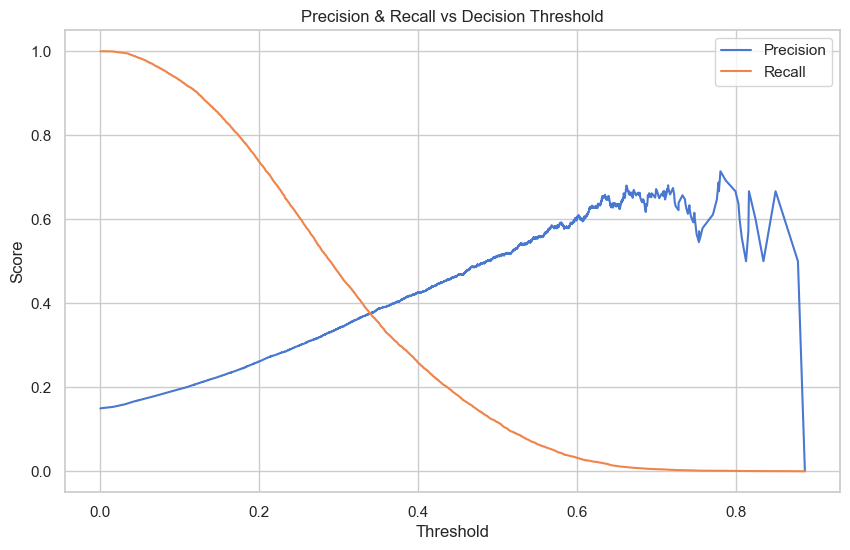

In [38]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# thresholds is shorter by 1
thresholds = thresholds

plt.figure(figsize=(10,6))

plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Decision Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# Compute F1 score for each threshold combination
# Add a small epsilon to prevent division by zero errors
f1_scores = (2 * precision * recall) / (precision + recall + 1e-10)

# Locate the index of the highest F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"Best Threshold for F1-Score Calibrated: {best_threshold:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f}")
print(f"Corresponding Precision: {precision[best_idx]:.4f}")
print(f"Corresponding Recall: {recall[best_idx]:.4f}")


Best Threshold for F1-Score Calibrated: 0.2625
Max F1-Score: 0.4020
Corresponding Precision: 0.3095
Corresponding Recall: 0.5732


Confusion Matrix Analysis

Using the optimized classification threshold of 0.2625, the model achieved a balance between identifying defaulted loans and limiting false alarms. At this threshold, the model produced a recall of 57.32%, meaning it successfully identified more than half of all defaulted loans in the test set.

The confusion matrix shows that:

* 36,746 loans were correctly classified as non-defaults (True Negatives).
* 4,767 loans were correctly classified as defaults (True Positives).
* 10,636 loans were incorrectly flagged as defaults when they did not default (False Positives).
* 3,549 loans were incorrectly classified as non-defaults when they eventually defaulted (False Negatives).

A key objective in credit risk modeling is reducing false negatives because these represent borrowers who default but are predicted to be low risk. Compared to a traditional threshold of 0.50, the optimized threshold substantially increased recall, allowing the model to identify many more potentially risky borrowers.

This improvement comes at the cost of additional false positives, which lowers precision to 30.95%. However, in many lending applications, the cost of missing a defaulted loan is significantly greater than the cost of reviewing or rejecting a borrower who would have ultimately repaid. For this reason, the chosen threshold prioritizes recall while still maintaining a reasonable precision level.

The resulting F1 score of 0.4020 reflects a substantially better balance between precision and recall than the default threshold, making the optimized threshold more appropriate for identifying high-risk borrowers in this credit risk prediction task.

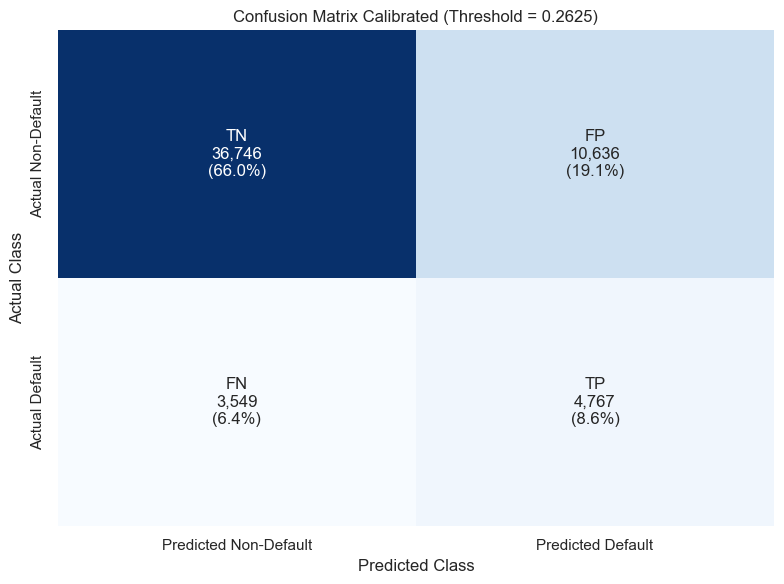

In [40]:
# Choose threshold
threshold = 0.2625
y_prob= iso_model.predict_proba(X_test)[:,1]
# Convert probabilities to predictions
y_pred = (y_prob >= threshold).astype(int)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Calculate percentages
cm_percent = cm / cm.sum() * 100

# Create labels with counts and percentages
labels = np.array([
    [
        f"TN\n{cm[0,0]:,}\n({cm_percent[0,0]:.1f}%)",
        f"FP\n{cm[0,1]:,}\n({cm_percent[0,1]:.1f}%)"
    ],
    [
        f"FN\n{cm[1,0]:,}\n({cm_percent[1,0]:.1f}%)",
        f"TP\n{cm[1,1]:,}\n({cm_percent[1,1]:.1f}%)"
    ]
])

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Non-Default", "Predicted Default"],
    yticklabels=["Actual Non-Default", "Actual Default"]
)
plt.title(f"Confusion Matrix Calibrated (Threshold = {threshold:.4f})")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()
plt.show()

## Performance Across Loan Grades

### Overview

This section evaluates model performance across loan grades (A–G), where grades represent increasing levels of borrower risk. Loan grades are assigned by Lending Club and reflect the creditworthiness of borrowers, with Grade A representing the lowest-risk loans and Grade G representing the highest-risk loans.

The objective of this analysis is to determine whether model performance remains consistent across different borrower risk segments and to identify any groups where predictive performance deteriorates.

---

### 1. AUC (Ranking Performance)

AUC measures the model's ability to rank borrowers who default higher than borrowers who do not default within each loan grade.

The calibrated model achieved the following AUC scores:

| Grade | AUC |
|---------|---------|
| A | 0.746 |
| B | 0.693 |
| C | 0.691 |
| D | 0.673 |
| E | 0.700 |
| F | 0.651 |
| G | 0.660 |

The highest performance was observed in **Grade A (0.746)**, while the lowest performance occurred in **Grade F (0.651)**. Although performance declines somewhat for higher-risk grades, the reduction is relatively modest. Across all grades, AUC remains above 0.65, indicating that the model maintains meaningful discriminatory power regardless of borrower risk level.

Comparing the calibrated model to the uncalibrated model shows improvements across every loan grade, suggesting that calibration enhanced the model's ranking performance while preserving stability across subgroups.

---

### 2. Average Precision (AP)

Average Precision (AP) evaluates performance on the positive class and is particularly informative for imbalanced classification problems such as default prediction.

The calibrated model achieved the following AP scores:

| Grade | AP |
|---------|---------|
| A | 0.142 |
| B | 0.237 |
| C | 0.332 |
| D | 0.403 |
| E | 0.462 |
| F | 0.488 |
| G | 0.492 |

A clear upward trend is visible as loan grade risk increases. Higher-risk grades naturally contain larger proportions of defaults, which makes identifying positive cases easier and results in higher AP values.

This pattern should not be interpreted as the model being inherently "better" for high-risk borrowers. Rather, it reflects differences in class prevalence across grades. Because default events are more common in Grades E–G, precision-recall metrics naturally improve.

---

### 3. Sample Size Distribution

Loan grades are not evenly represented within the dataset.

| Grade | Count |
|---------|---------|
| A | 218,051 |
| B | 369,825 |
| C | 364,788 |
| D | 190,489 |
| E | 88,231 |
| F | 29,944 |
| G | 8,494 |

Grades B and C contain the largest number of observations, while Grades F and G represent relatively small portions of the dataset.

Because of their limited sample sizes, performance estimates for Grades F and G are more susceptible to statistical variation and should be interpreted with greater caution than the results for Grades A–E.

---

### 4. Fairness and Robustness

Several important observations emerge from the subgroup analysis:

- The model maintains AUC values above 0.65 across all loan grades.
- No subgroup experiences catastrophic performance degradation.
- Calibration improved both AUC and AP across every grade.
- Performance differences between grades are relatively small compared with the overall predictive strength of the model.
- The model demonstrates stable behavior across both low-risk and high-risk borrower populations.

Notably, calibration improved AUC in every loan grade subgroup, indicating that the calibration process enhanced probability estimation without sacrificing discriminatory performance.

These results suggest that the model is robust across borrower risk segments and does not exhibit evidence of severe subgroup bias based on loan grade.

---

### Conclusion

The calibrated model demonstrates consistent predictive performance across all Lending Club loan grades. While performance is strongest in lower-risk grades and gradually decreases for higher-risk borrowers, the decline is moderate and expected given the increased uncertainty associated with high-risk lending populations.

Calibration improved performance across all grades, resulting in stronger ranking ability and improved precision-recall characteristics. Overall, the subgroup analysis indicates that the model generalizes well across borrower risk tiers and provides reliable predictions throughout the full spectrum of loan grades.

In [41]:
def subgroup_auc(df, X, y, model, col):
    results = []

    for group in df[col].unique():
        mask = df[col] == group

        X_group = X.loc[mask]
        y_group = y.loc[mask]

        probs = model.predict_proba(X_group)[:, 1]
        auc = roc_auc_score(y_group, probs)
        pr_auc = average_precision_score(y_group, probs)

        results.append((group, auc,pr_auc, mask.sum()))

    return pd.DataFrame(results, columns=[col, "AUC", "AP","count"]).sort_values("AUC", ascending=False)

grade_results = subgroup_auc(df, X_test, y_test, iso_model, "grade")
grade_results_default = subgroup_auc(df, X_test, y_test, cat_boost_model, "grade")
print("catboost subgroups uncalibrated:")
print(grade_results_default)
print("calibrated subroups")
print(grade_results)



catboost subgroups uncalibrated:
  grade       AUC        AP   count
1     A  0.705765  0.102984  218051
4     E  0.686956  0.447235   88231
3     C  0.663485  0.308680  364788
0     B  0.660511  0.195590  369825
2     D  0.655922  0.375575  190489
6     G  0.639276  0.535469    8494
5     F  0.630396  0.460742   29944
calibrated subroups
  grade       AUC        AP   count
1     A  0.745994  0.142143  218051
4     E  0.699691  0.461697   88231
0     B  0.692618  0.236966  369825
3     C  0.690549  0.332491  364788
2     D  0.672941  0.402542  190489
6     G  0.659819  0.492252    8494
5     F  0.650975  0.487659   29944


# Failure Mode Analysis

## Overview

This section evaluates model errors by categorizing predictions into three groups:

- Correct predictions
- False positives (non-default loans incorrectly classified as defaults)
- False negatives (defaulted loans incorrectly classified as non-defaults)

The objective is to determine whether prediction errors occur randomly or are concentrated within specific borrower segments and probability regions. Understanding these failure patterns helps identify areas where the model performs well and where additional improvement may be possible.

## Overall Error Distribution

At the selected classification threshold, the calibrated model produced the following distribution of prediction outcomes:

| Error Type | Proportion |
|------------|------------|
| Correct | 74.5% |
| False Positive | 19.1% |
| False Negative | 6.4% |

### Interpretation

The model correctly classifies approximately three-quarters of all observations. False positives occur more frequently than false negatives, indicating that the model tends to be conservative when assigning default risk.

From a credit risk perspective, this behavior is often desirable because the cost of missing a true default is typically greater than the cost of incorrectly flagging a borrower as risky.

## Hard Case Analysis

Hard cases were defined as observations located within the model's uncertainty region.

| Error Type | Proportion |
|------------|------------|
| Correct | 88.3% |
| False Negative | 11.7% |
| False Positive | 0.0% |

### Interpretation

Within the uncertainty region, the model continues to perform well, correctly classifying approximately 88% of observations. The remaining errors are entirely false negatives.

This suggests that when the model is uncertain, it tends to classify borrowers as lower risk rather than aggressively predicting default. The absence of false positives indicates that the calibrated model does not systematically overestimate risk near the decision boundary.

## Failure Rates by Loan Grade

The following table summarizes prediction outcomes across loan grades.

| Grade | Correct | False Negative | False Positive |
|---------|---------|---------|---------|
| A | 95.1% | 4.5% | 0.4% |
| B | 85.3% | 8.3% | 6.4% |
| C | 66.8% | 7.5% | 25.7% |
| D | 52.0% | 5.4% | 42.6% |
| E | 50.0% | 3.4% | 46.6% |
| F | 44.4% | 1.9% | 53.8% |
| G | 41.0% | 4.5% | 54.5% |

### Interpretation

Several clear trends emerge:

- Correct classification rates decline as borrower risk increases.
- False positive rates increase substantially from Grades C through G.
- False negative rates remain relatively low across all grades.

The model performs best on low-risk borrowers (Grades A and B), where correct classification rates exceed 85%. Performance gradually decreases as borrower risk increases, largely because of rising false positive rates rather than missed defaults.

## False Negative Analysis

Because false negatives represent missed defaults, they are often considered the most important error type in credit risk modeling.

| Grade | False Negative Rate |
|---------|---------|
| B | 8.3% |
| C | 7.5% |
| D | 5.4% |
| A | 4.5% |
| G | 4.5% |
| E | 3.4% |
| F | 1.9% |

### Interpretation

The highest false negative rates occur in Grades B and C rather than in the highest-risk borrower segments.

This finding suggests that missed defaults are concentrated among borrowers who appear relatively safe based on observed characteristics. Conversely, the model rarely misses defaults among the highest-risk grades, indicating strong sensitivity to clearly risky borrowers.

## Key Findings

The failure mode analysis reveals several important patterns:

- The model correctly classifies approximately 75% of all observations.
- False positives occur more frequently than false negatives.
- Model performance is strongest among low-risk borrower grades.
- High-risk grades experience elevated false positive rates but relatively few missed defaults.
- Most false negatives occur within Grades B and C.
- The model exhibits a conservative risk profile, prioritizing default detection over minimizing false alarms.

## Conclusion

The model's errors are not randomly distributed throughout the dataset. Instead, failures are concentrated within specific borrower segments.

Most false positives occur among higher-risk loan grades, while most false negatives occur among moderate-risk borrowers whose characteristics resemble those of non-defaulting applicants. The relatively low false negative rates across high-risk grades indicate that the model successfully identifies the majority of truly risky borrowers.

Overall, the results suggest that the calibrated model behaves consistently with the objectives of a credit risk system by emphasizing default detection while maintaining acceptable overall predictive performance.

In [42]:
threshold = 0.2625 # optimized on the SAME probability space you use below

# 3. predictions using shifted probabilities
y_pred = (y_prob >= threshold).astype(int)

# 4. build evaluation frame
failure_df = X_test.copy()
failure_df["grade"] = df.loc[X_test.index, "grade"].values
failure_df["y_true"] = y_test.values
failure_df["y_proba"] = y_prob
failure_df["y_pred"] = y_pred

# 5. define error types
failure_df["error_type"] = "correct"
failure_df.loc[
    (failure_df["y_true"] == 1) & (failure_df["y_pred"] == 0),
    "error_type"
] = "false_negative"

failure_df.loc[
    (failure_df["y_true"] == 0) & (failure_df["y_pred"] == 1),
    "error_type"
] = "false_positive"

In [43]:
print("calibrated:\n")
print("total failure:")
print(failure_df["error_type"].value_counts(normalize=True))

# define hard cases using quantiles (stable under shifting/calibration)
low = failure_df["y_proba"].quantile(0.4)
high = failure_df["y_proba"].quantile(0.6)

hard_cases = failure_df[
    (failure_df["y_proba"] >= low) &
    (failure_df["y_proba"] <= high)
]
print("\nhard_cases failure:")
print(hard_cases["error_type"].value_counts(normalize=True))

grade_fail = failure_df.groupby("grade")["error_type"].value_counts(normalize=True).unstack()
print("failure rate by grade: ")
print(grade_fail)

total_by_grade = failure_df.groupby("grade").size()

fn_by_grade = (
    failure_df.loc[failure_df["error_type"] == "false_negative"]
    .groupby("grade")
    .size()
)

fn_rate_by_grade = fn_by_grade.reindex(total_by_grade.index, fill_value=0) / total_by_grade

print("false neg rate by grade:\n",fn_rate_by_grade.sort_values(ascending=False))

calibrated:

total failure:
error_type
correct           0.745323
false_positive    0.190958
false_negative    0.063719
Name: proportion, dtype: float64

hard_cases failure:
error_type
correct           0.882585
false_negative    0.117415
Name: proportion, dtype: float64
failure rate by grade: 
error_type   correct  false_negative  false_positive
grade                                               
A           0.950969        0.044873        0.004158
B           0.852666        0.083008        0.064326
C           0.668105        0.074706        0.257190
D           0.519453        0.054048        0.426498
E           0.500169        0.034110        0.465721
F           0.443586        0.018547        0.537867
G           0.410448        0.044776        0.544776
false neg rate by grade:
 grade
B    0.083008
C    0.074706
D    0.054048
A    0.044873
G    0.044776
E    0.034110
F    0.018547
dtype: float64


## Bootstrap ROC AUC


## ROC-AUC with Confidence Intervals

### Overview

The ROC-AUC metric evaluates the model’s ability to correctly rank defaulted borrowers above non-defaulted borrowers across all decision thresholds.

To assess the stability of this metric, a **bootstrap-based confidence interval** was computed.

---

### Result

- **ROC-AUC:** 0.735  
- **95% Confidence Interval:** [0.748, 0.759]

---

### Interpretation

The narrow confidence interval indicates that the ROC-AUC estimate is **statistically stable across resampled test sets**. This suggests that the model’s ranking performance is not highly sensitive to sampling variation and is likely to generalize reliably to unseen data.

---

### Key Insight

The model demonstrates **consistent discriminatory power**, with minimal variance in ROC-AUC across bootstrap samples, indicating robust ranking behavior.

In [44]:
n_bootstraps = 1000
roc_scores = []
test_probs  = iso_model.predict_proba(X_test)[:, 1]


rng = np.random.default_rng(42)

for _ in range(n_bootstraps):

    idx = rng.choice(len(y_test), size=len(y_test), replace=True)
    y_boot = y_test.iloc[idx]
    p_boot = test_probs[idx]

    if len(np.unique(y_boot)) < 2:
        continue

    roc_scores.append(roc_auc_score(y_boot, p_boot))

In [45]:
lower = np.percentile(roc_scores, 2.5)
upper = np.percentile(roc_scores, 97.5)

print(f"ROC AUC: {np.mean(roc_scores):.3f}")
print(f"95% CI: [{lower:.3f}, {upper:.3f}]")

ROC AUC: 0.753
95% CI: [0.748, 0.759]


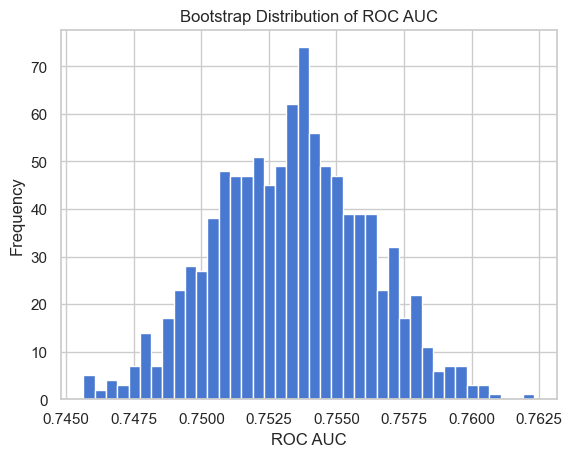

In [46]:
plt.hist(roc_scores, bins=40)
plt.xlabel("ROC AUC")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of ROC AUC")
plt.show()

# PR-AUC with Confidence Intervals

## Overview

The Precision-Recall AUC (PR-AUC) evaluates model performance under class imbalance, focusing on how well the model identifies positive (default) cases.

This metric is especially important in credit risk modeling due to the low default rate.

---

## Result

- **PR-AUC:** 0.351  
- **95% Confidence Interval:** [0.341, 0.362]

---

## Interpretation

The relatively tight confidence interval indicates that PR-AUC is **stable across bootstrap samples**, suggesting consistent performance in identifying default cases despite class imbalance.

The narrow range shows that model performance is **not overly sensitive to data sampling variation**, reinforcing reliability in imbalanced classification settings.

---

## Key Insight

The model maintains **stable precision-recall tradeoffs**, indicating reliable performance in detecting defaults across different sampled datasets.

In [47]:
pr_scores = []

for _ in range(n_bootstraps):

    idx = rng.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    y_boot = y_test.iloc[idx]
    p_boot = test_probs[idx]

    if len(np.unique(y_boot)) < 2:
        continue

    pr_scores.append(
        average_precision_score(y_boot, p_boot)
    )

In [48]:
lower = np.percentile(pr_scores, 2.5)
upper = np.percentile(pr_scores, 97.5)

print(f"PR AUC: {np.mean(pr_scores):.3f}")
print(f"95% CI: [{lower:.3f}, {upper:.3f}]")

PR AUC: 0.351
95% CI: [0.341, 0.362]


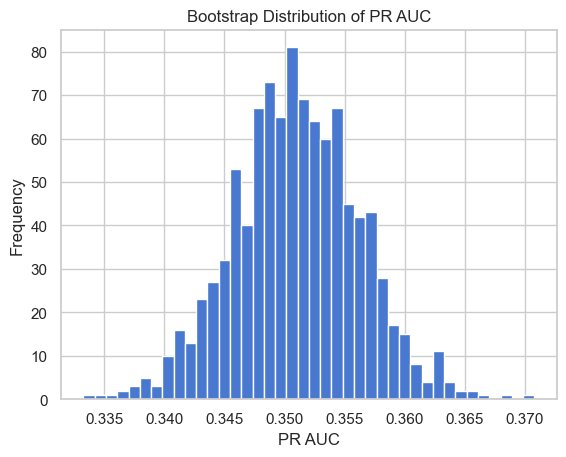

In [49]:
plt.hist(pr_scores, bins=40)
plt.xlabel("PR AUC")
plt.ylabel("Frequency")
plt.title("Bootstrap Distribution of PR AUC")
plt.show()

# Default Rate Stability (Bootstrap)

## Method

The test set default rate was estimated under sampling uncertainty using bootstrap resampling. In each iteration, the test set was resampled with replacement and the mean default rate was computed.

This produces an empirical distribution of possible default rates.

---

## Result

- **95% Confidence Interval:** [0.1460, 0.1524]

---

## Interpretation

The default rate is highly stable across bootstrap samples, indicating low sensitivity to sampling variation. This suggests that the observed class imbalance (~15% default rate) is a reliable estimate of the underlying population rate.

---

## Key Insight

The narrow confidence interval confirms that evaluation metrics (e.g., PR-AUC and calibration) are computed on a statistically stable class distribution.

In [50]:
default_rates = []

for _ in range(n_bootstraps):

    idx = rng.choice(
        len(y_test),
        size=len(y_test),
        replace=True
    )

    default_rates.append(
        y_test.iloc[idx].mean()
    )

In [51]:
np.percentile(default_rates, [2.5, 97.5])

array([0.14600075, 0.15237531])

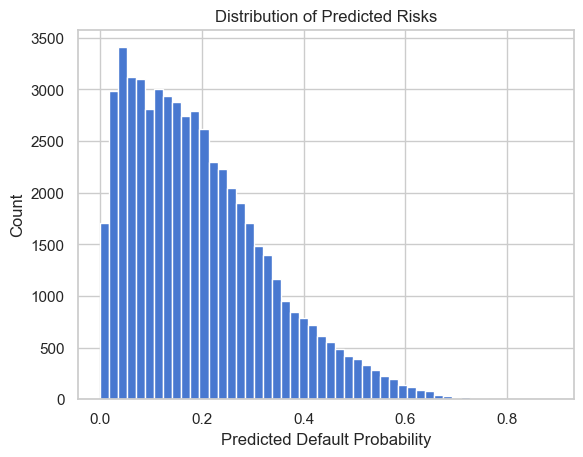

In [52]:
plt.hist(test_probs, bins=50)
plt.xlabel("Predicted Default Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Risks")
plt.show()

In [53]:
import joblib
import pickle

# everything your serving code needs
artifact = {
    "model": iso_model,                          # calibrated CatBoost
    "features": X_test.columns.tolist(),          # final feature list (after both pruning steps)
    "cat_features": categorical_cols,             # categorical column names
    "threshold": 0.2625,                          # optimized decision threshold
}

joblib.dump(artifact, "../models/loan_default_model.pkl")

['../models/loan_default_model.pkl']

In [54]:
# Option 2: Using joblib (better for scikit-learn/LightGBM)
joblib.dump(cat_boost_model, '../models/catboost_model.pkl')


['../models/catboost_model.pkl']